**Project:** Data Mining II (2025/26)

**Group Number:** 12

**Members:**
- Beatriz Boura - 20250272
- Dinis Gaspar - 20221869
- Margarida Cruz - 20221929

**Project Overview**

In recent years, nonprofit organizations have faced a growing challenge: while charitable causes have multiplied, public tolerance for repeated, generic solicitations has significantly decreased, often leading to donor fatigue and long-term disengagement. To address this issue, the Civic Support Alliance (CSA)—a federation representing multiple humanitarian and social aid programs—seeks to modernize its fundraising strategy. Rather than launching blanket campaigns across their entire database, the organization aims to transition to a highly targeted approach. The goal is to maximize operational efficiency and maintain donor respect by contacting fewer, but more receptive, individuals. 

As data scientists, our team has been tasked with building a predictive machine learning system using historical demographic, interaction, and donation data accumulated from past campaigns. The primary objective is to accurately answer a fundamental question: Will this person donate if contacted? 

**Notebook Introduction**

In this notebook, we will develop Tree-based models, we will find parameter regions using our hold-out method splits as explained in the Modeling Tools notebook to test and we will then perform a parameter search to try and maximize performances.

**Benchmarks**

As the goal of this project is to help the CSA create and improve a targeted approach to donors with the goal of maximizing donations, we will use 2 baseline benchmarks as the minimum any model must achieve to be a good model:
+ Random prediction, which in a dataset with the imbalance present in the CSA's data yield an **F1-Score of ~0.34**
+ Predicting all 1, which is essentially, telling the CSA to keep sending out the camapaign to everyone. This is obviously not the desire of the CSA and as such the goal is to create models that can avoid this. Predicting all 1 in a dataset with this imbalance yields an **F1-Score of 0.4**

**Table of contents**<a id='toc0_'></a>    
1. [Imports](#toc1_)    
2. [Defining the Pipeline](#toc2_)    
3. [Base Model](#toc3_)    
4. [Model with Threshold optimization](#toc4_)    
5. [Maximum Depth](#toc5_)    
6. [Split Criterion](#toc6_)    
7. [Minimum Weight Fraction Leaf](#toc7_)    
8. [Minimum Samples to Split](#toc8_)    
9. [Parameter Search](#toc9_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=3
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Imports](#toc0_)

In this section we're importing everything we need, libraries and tools.

In [31]:
from sklearnex import patch_sklearn
patch_sklearn()
from utils_modeling import (OutlierClipper, CategoricalFeatureSelector, NumericalFeatureSelector, FeatureEngineer, DataCleaner, run_parameter_search)
import os
if os.getcwd() != 'c:\\Users\\dinis\\OneDrive\\Ambiente de Trabalho\\Faculdade - MGI-BI\\1º ano\\2º Semestre\\Data Mining II\\Project\\DM2_Project':
    %cd ..
import numpy as np
import pandas as pd
from sklearn.model_selection import TunedThresholdClassifierCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")
SEED=23
pd.options.display.max_columns = None

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [32]:
train = pd.read_csv('Files/donors_train.csv')
with open('Files/Pickle Files/model_testing_skf.pkl', 'rb') as file:
    model_testing_skf = pickle.load(file)
with open('Files/Pickle Files/data_cleaner.pkl', 'rb') as file:
    data_cleaner = pickle.load(file)
with open('Files/Pickle Files/X_train_preprocessed.pkl', 'rb') as file:
    X_train_preprocessed = pickle.load(file)
with open('Files/Pickle Files/X_val_preprocessed.pkl', 'rb') as file:
    X_val_preprocessed = pickle.load(file)
with open('Files/Pickle Files/y_train.pkl', 'rb') as file:
    y_train = pickle.load(file)
with open('Files/Pickle Files/y_val.pkl', 'rb') as file:
    y_val = pickle.load(file)

In [33]:
X = train.drop('TARGET_B', axis=1)
y = train['TARGET_B']

# 2. <a id='toc2_'></a>[Defining the Pipeline](#toc0_)

We're first going to start by defining the pipeline we're gonna use as a base. This is the pipeline introduced in the Modeling Tools notebook, now with a DecisionTreeClassifier model.

In [34]:
# Categorical Feature Sub-Pipeline
# This is the part that handles the categorical columns, performing
# mode imputation, feature selection using our custom CategoricalFeatureSelector
# and finally one-hot encoding the features.
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('feature_selection',  CategoricalFeatureSelector()),
    # 3. Your specialized encoding (OneHot/Target) now receives imputed integers
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

# Numerical Feature Sub-Pipeline
# Here we take care of our numerical features, starting with outlier clipping and feature
# creation using our custom transformer, then scaling data, so that it can then 
# be imputed and numerical feature selection can be performed
num_pipe = Pipeline([
    ('clipper', OutlierClipper()),
    ('feature_engineer', FeatureEngineer()),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer()),
    ('feature_selection', NumericalFeatureSelector(random_state=SEED))
])

# Here we use a ColumnTransformer with column selectors to perform the split
# between numerical and categorical data, so that each subset can be directed
# to the appropriate sub-pipeline
preprocessor = ColumnTransformer([
    ('cat_section', cat_pipe, make_column_selector(dtype_exclude=[np.number])),
    ('num_section', num_pipe, make_column_selector(dtype_include=[np.number])),
],
verbose_feature_names_out=False)
#  

 
# Final Pipeline
dt_pipe = Pipeline([
    ('cleaner', data_cleaner),
    ('preprocessing', preprocessor),
    ('model', TunedThresholdClassifierCV(DecisionTreeClassifier(random_state=SEED),
                                         n_jobs=-1,
                                         scoring='f1',
                                         random_state=SEED,
                                         cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
                                         )) 
])

# We use the set_output to pandas so that intermediate transformers can use column
# names, since some of the default scikit-learn transformers by default return 
# Numpy arrays, which obviously don't have column names.
dt_pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_cols_values,"{'DONOR_GENDER': ['M', 'F', ...], 'INCOME_GROUP': array([1, 2, 3, 4, 5, 6, 7]), 'PEP_STAR': [0, 1], 'RECENCY_STATUS_96NK': ['S', 'A', ...], ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that

Now let's start looking at models and results.

# 3. <a id='toc3_'></a>[Base Model](#toc0_)

We'll start by testing a base un-pruned model.

In [5]:
dt_base = DecisionTreeClassifier(random_state=SEED)
dt_base.fit(X_train_preprocessed, y_train)
dt_pred_train = dt_base.predict(X_train_preprocessed)
dt_pred_val = dt_base.predict(X_val_preprocessed)
print(f"Base Model F1-Score in Training: {f1_score(y_train, dt_pred_train)}")
print(f"Base Model F1-Score in Validation: {f1_score(y_val, dt_pred_val)}")

Base Model F1-Score in Training: 1.0
Base Model F1-Score in Validation: 0.27766323024054984


Right away, it becomes clear that the default unpruned tree model model without threshold optimization performs very poorly and with massive overfitting, significantly worse than random or all 1 prediction. We'll now see the impact of threshold optimization on the performance.

# 4. <a id='toc4_'></a>[Model with Threshold optimization](#toc0_)

In [6]:
dt_thresh_opt = TunedThresholdClassifierCV(DecisionTreeClassifier(random_state=SEED),
                                            n_jobs=-1,
                                            scoring='f1',
                                            random_state=SEED)
dt_thresh_opt.fit(X_train_preprocessed, y_train)
thresh_op_pred_train = dt_thresh_opt.predict(X_train_preprocessed)
thresh_op_pred_val = dt_thresh_opt.predict(X_val_preprocessed)
print(f"Threshold Oprimized Base Model F1-Score in Training: {f1_score(y_train, thresh_op_pred_train)}")
print(f"Threshold Oprimized Base Model F1-Score in Validation: {f1_score(y_val, thresh_op_pred_val)}")
print(f'Optmized Threshold: {dt_thresh_opt.best_threshold_}')

Threshold Oprimized Base Model F1-Score in Training: 0.4
Threshold Oprimized Base Model F1-Score in Validation: 0.4
Optmized Threshold: 0.0


As expected from the poor performance of the base model the threshold optimization reduces the threshold to 0, generating only 1 as the predicted values, this is somewhat expected, since with an unruned tree leaf nodes will have very few observations, meaning the prediction probability will 0 or 1. This allows us to conclude that for this problem, the base unpruned tree model has no predictive power and as such we must look for improvements using its parameters. 

# 5. <a id='toc5_'></a>[Maximum Depth](#toc0_)

The base DecisionTree model, even with threshold optimization, is not providing any predictive power, this is likely down to the massive overfitting we could see in the base model. Limiting the maximum depth is usually the simplest most straightforward way to prune a tree and combat overfitting.

In [18]:
depth_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for depth in tqdm(depth_list):
    dt_depth_model = TunedThresholdClassifierCV(DecisionTreeClassifier(
        random_state=SEED,
        max_depth=depth),
        n_jobs=-1,
        scoring='f1',
        random_state=SEED)
    dt_depth_model.fit(X_train_preprocessed, y_train)
    train_pred = dt_depth_model.predict(X_train_preprocessed)
    val_pred = dt_depth_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = depth_list[depth-1]


print("Best maximum Depth: %d" %nof)
print("Mean F1 score in train with %d maximum depth: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d maximum depth: %f" % (nof, high_score))

  0%|          | 0/19 [00:00<?, ?it/s]

Best maximum Depth: 4
Mean F1 score in train with 4 maximum depth: 0.417839
Mean F1 score in validation with 4 maximum depth: 0.402839


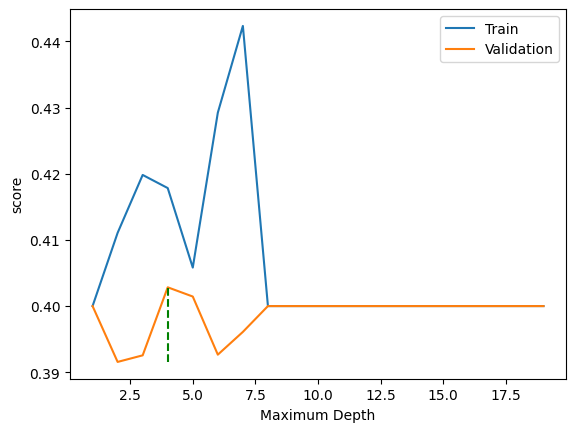

In [8]:
plt.plot(depth_list, scores_train, label='Train')
plt.plot(depth_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xlabel('Maximum Depth')
plt.ylabel('score')
plt.legend()

plt.show()

It's clear that a maximum depth above 7 is not producing meaningful models, and it looks like the ideal value is around 4 or 5. For testing purposes we will use 4 to 7 as the optimal value may change based on other model parameters and preprocessing parameters. For finding other parameter regions going forward we'll use max_depth 4 in the models.

# 6. <a id='toc6_'></a>[Split Criterion](#toc0_)

The criterion parameter defines the mathematical function used to measure the quality of a split by calculating node impurity.

In [38]:
dt_class_entropy = TunedThresholdClassifierCV(DecisionTreeClassifier(random_state=SEED,
                                                               criterion='entropy',
                                                               max_depth=4),
                                            n_jobs=-1,
                                            scoring='f1',
                                            random_state=SEED)
dt_class_entropy.fit(X_train_preprocessed, y_train)
entropy_pred_train = dt_class_entropy.predict(X_train_preprocessed)
entropy_pred_val = dt_class_entropy.predict(X_val_preprocessed)
print(f"Entropy Criterion Model F1-Score in Training: {f1_score(y_train, entropy_pred_train)}")
print(f"Entropy Crierion Model F1-Score in Validation: {f1_score(y_val, entropy_pred_val)}")
print(f'Optmized Threshold: {dt_class_entropy.best_threshold_}')

Entropy Criterion Model F1-Score in Training: 0.42107212295157853
Entropy Crierion Model F1-Score in Validation: 0.3988418385812523
Optmized Threshold: 0.20202020202020204


In [39]:
dt_class_entropy = TunedThresholdClassifierCV(DecisionTreeClassifier(random_state=SEED,
                                                               criterion='gini',
                                                               max_depth=4),
                                            n_jobs=-1,
                                            scoring='f1',
                                            random_state=SEED)
dt_class_entropy.fit(X_train_preprocessed, y_train)
entropy_pred_train = dt_class_entropy.predict(X_train_preprocessed)
entropy_pred_val = dt_class_entropy.predict(X_val_preprocessed)
print(f"Entropy Criterion Model F1-Score in Training: {f1_score(y_train, entropy_pred_train)}")
print(f"Entropy Crierion Model F1-Score in Validation: {f1_score(y_val, entropy_pred_val)}")
print(f'Optmized Threshold: {dt_class_entropy.best_threshold_}')

Entropy Criterion Model F1-Score in Training: 0.417839174554447
Entropy Crierion Model F1-Score in Validation: 0.4028387968908415
Optmized Threshold: 0.20202020202020204


In [40]:
dt_class_entropy = TunedThresholdClassifierCV(DecisionTreeClassifier(random_state=SEED,
                                                               criterion='log_loss',
                                                               max_depth=4),
                                            n_jobs=-1,
                                            scoring='f1',
                                            random_state=SEED)
dt_class_entropy.fit(X_train_preprocessed, y_train)
entropy_pred_train = dt_class_entropy.predict(X_train_preprocessed)
entropy_pred_val = dt_class_entropy.predict(X_val_preprocessed)
print(f"Entropy Criterion Model F1-Score in Training: {f1_score(y_train, entropy_pred_train)}")
print(f"Entropy Crierion Model F1-Score in Validation: {f1_score(y_val, entropy_pred_val)}")
print(f'Optmized Threshold: {dt_class_entropy.best_threshold_}')

Entropy Criterion Model F1-Score in Training: 0.42107212295157853
Entropy Crierion Model F1-Score in Validation: 0.3988418385812523
Optmized Threshold: 0.20202020202020204


It seems like the gini criterion is the only providing better results than the benchmarks, as such we will only test gini (default) criterion in the parameter search and will instead focus on other parameters.. 

# 7. <a id='toc7_'></a>[Minimum Weight Fraction Leaf](#toc0_)

The min_weight_fraction_leaf parameter defines the minimum percentage of the total input sample weight that must end up in a terminal leaf node for it to be created. Since we want to aggressively prevent overfitting by requiring significant data weight in each leaf, we will test values between 0.00 and 0.40 in steps of 0.005.

In [ ]:
min_weight_list = np.arange(0, 0.4, 0.005)
scores_train = []
scores_val = []
high_score=0
nof=0
for i in tqdm(range(len(min_weight_list))):
    dt_min_weight_model = TunedThresholdClassifierCV(DecisionTreeClassifier(
        random_state=SEED,
        min_weight_fraction_leaf=min_weight_list[i]),
        n_jobs=-1,
        scoring='f1',
        random_state=SEED)
    dt_min_weight_model.fit(X_train_preprocessed, y_train)
    train_pred = dt_min_weight_model.predict(X_train_preprocessed)
    val_pred = dt_min_weight_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        best_min_weight = i


print(f"Best Minimum Leaf Weight: {min_weight_list[best_min_weight]}")
print("Mean F1 score in train with {} minimum weight fraction leaf: {}".format(min_weight_list[best_min_weight], scores_train[best_min_weight]))
print("Mean F1 score in validation with {} minimum weight fraction leaf: {}".format(min_weight_list[best_min_weight], high_score))

  0%|          | 0/80 [00:00<?, ?it/s]

Best Minimum Leaf Weight: 0.03
Mean F1 score in train with 0.03 minimum weight fraction leaf: 0.42277531537674734
Mean F1 score in validation with 0.03 minimum weight fraction leaf: 0.408135593220339


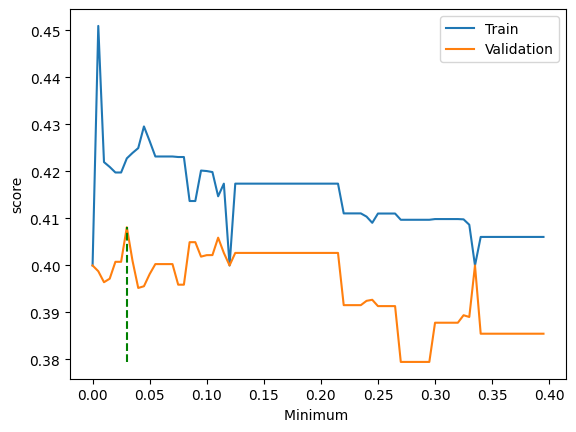

In [ ]:
plt.plot(min_weight_list, scores_train, label='Train')
plt.plot(min_weight_list, scores_val, label = 'Validation')
plt.vlines(x=min_weight_list[best_min_weight],ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xlabel('Minimum Leaf Weight')
plt.ylabel('score')
plt.legend()

plt.show()

We can see that a value between 0.03 and 0.06 is the sweet spot, in this case the peak is at 0.03.

# 8. <a id='toc8_'></a>[Minimum Samples to Split](#toc0_)

The Minimum samples to split parameter is simply in that it defines the minimum number of observation a tree node must have for a split to be performed. Since we have a decently large dataset we'll test values between 2 and 99.

In [65]:
min_samples_list = np.arange(2, 100)
scores_train = []
scores_val = []
high_score=0
nof=0
i = 0
for i in tqdm(range(len(min_samples_list))):
    dt_min_weight_model = TunedThresholdClassifierCV(DecisionTreeClassifier(
        random_state=SEED,
        min_samples_split=min_samples_list[i]),
        n_jobs=-1,
        scoring='f1',
        random_state=SEED)
    dt_min_weight_model.fit(X_train_preprocessed, y_train)
    train_pred = dt_min_weight_model.predict(X_train_preprocessed)
    val_pred = dt_min_weight_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        best_min_samples = i


print(f"Best Minimum Leaf Weight: {min_samples_list[best_min_samples]}")
print("Mean F1 score in train with {} minimum weight fraction leaf: {}".format(min_samples_list[best_min_samples], scores_train[best_min_samples]))
print("Mean F1 score in validation with {} minimum weight fraction leaf: {}".format(min_samples_list[best_min_samples], high_score))

  0%|          | 0/98 [00:00<?, ?it/s]

Best Minimum Leaf Weight: 90
Mean F1 score in train with 90 minimum weight fraction leaf: 0.43954619124797406
Mean F1 score in validation with 90 minimum weight fraction leaf: 0.40425531914893614


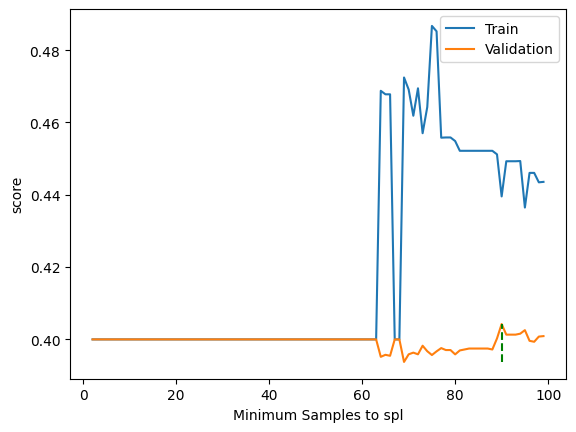

In [ ]:
plt.plot(min_samples_list, scores_train, label='Train')
plt.plot(min_samples_list, scores_val, label = 'Validation')
plt.vlines(x=min_samples_list[best_min_samples],ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xlabel('Minimum Samples to split')
plt.ylabel('score')
plt.legend()

plt.show()

Since it seems to have very little impact on scores, we will not use the minimum number of samples to split and will let other parameters handle pruning.

# 9. <a id='toc9_'></a>[Parameter Search](#toc0_)

It's now time to run the gridsearch, using our run_parameter_search function, based on the parameter regions we've found so far.

We're going to test several combinations across two separate sub-grids to optimize our preprocessing and modeling steps efficiently. This is because Decision Trees don't require scaling, and so scalers will only be used when the KNNImputer is also used, except for the PowerTransformer which corrects variable skewness:

+ In preprocessing:
    + Scaler: For distance-based imputation, we're going to test the MinMaxScaler, RobustScaler (which is similar to MinMax but uses quartile values to handle outliers), and finally the PowerTransformer which applies transformations to bring skewed distributions closer to a Normal distribution before scaling them to mean 0 and variance 1. For our iterative imputation path, we will skip the standard scalers and only test the PowerTransformer alongside a baseline of no scaling at all.
    + Imputer: We'll compare two advanced strategies: the distance-based KNNImputer (set to 50 neighbors) and the IterativeImputer (MICE). The Iterative Imputer uses its default BayesianRidge estimator to model each feature with missing values as a function of all other features in a round-robin fashion.
    + Clipping: We'll test 3 strategies for handling outliers: no clipping at all, and clipping based on the standard Interquartile Range (IQR) method using a multiplier of 1.5 to catch normal outliers and a multiplier of 3 for extreme outliers.
+ In the Model:
    + Tree Depth: We're tuning the max_depth across 4 different levels (from 3 to 6) to find the sweet spot between an underfitted model and an overfitted one.
    + Class Weight: To handle  data imbalances, we're testing a 'Balanced' approach, which automatically adjusts weights inversely proportional to class frequencies.
    + Leaf Regularization: We're testing 4 different values for min_weight_fraction_leaf (ranging from 0.03 to 0.06 in steps of 0.01) to ensure our terminal leaves require a minimum percentage of the total data weight, further preventing overfitting.

In [39]:
param_grid = [
    # Sub-grid for KNN Imputer 
    {
        'preprocessing__num_section__imputer' : [KNNImputer(n_neighbors=50)],
        'preprocessing__num_section__scaler' : [PowerTransformer(), MinMaxScaler(), RobustScaler()], 
        'preprocessing__num_section__clipper' : [None, OutlierClipper(method='iqr', iqr_multiplier=1.5), OutlierClipper(method='iqr', iqr_multiplier=3)],
        'model__estimator' : [DecisionTreeClassifier(class_weight='balanced', random_state=SEED)],
        'model__estimator__max_depth' : np.arange(3, 7),
        'model__estimator__min_weight_fraction_leaf' : np.arange(0.03, 0.07, 0.01)
    },
    
    # Sub-grid or Iterative Imputer 
    {
        'preprocessing__num_section__imputer' : [IterativeImputer(random_state=SEED, max_iter=10, initial_strategy='median')],
        'preprocessing__num_section__scaler' : [None, PowerTransformer()], # Skips basic scalers, keeps the distributional transform
        'preprocessing__num_section__clipper' : [None, OutlierClipper(method='iqr', iqr_multiplier=1.5), OutlierClipper(method='iqr', iqr_multiplier=3)],
        'model__estimator' : [DecisionTreeClassifier(class_weight='balanced', random_state=SEED)],
        'model__estimator__max_depth' : np.arange(3, 7),
        'model__estimator__min_weight_fraction_leaf' : np.arange(0.03, 0.07, 0.01)
    }
]

```python
run_parameter_search(grid=param_grid,
                     cv=model_testing_skf, 
                     X=X, y=y,
                     model=dt_pipe,
                     metrics=['f1', 'precision', 'recall'],
                     results_file_dir='Files/Pickle Files/Results/DT_GridSearch_Results.pkl',
                     model_file_dir='Files/Pickle Files/Models/DT_GridSearch_Best_Model.pkl',
                     refit=True,
                     n_jobs=-1)

In [43]:
result_df = pd.read_pickle('Files\Pickle Files\Results\DT_GridSearch_Results.pkl')
result_df.head()

,params_config,model__estimator,model__estimator__max_depth,model__estimator__min_weight_fraction_leaf,preprocessing__num_section__clipper,preprocessing__num_section__imputer,preprocessing__num_section__scaler,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status
204,{'model__estimator': DecisionTreeClassifier(cl...,DecisionTreeClassifier(class_weight='balanced'...,3,0.07,None,"IterativeImputer(initial_strategy='median', ra...",None,53.217713,0.411342,0.003255,0.415477,0.003307,0.272363,0.009296,0.274292,0.009173,0.848968,0.071825,0.863274,0.060660,Success
186,{'model__estimator': DecisionTreeClassifier(cl...,DecisionTreeClassifier(class_weight='balanced'...,3,0.04,None,"IterativeImputer(initial_strategy='median', ra...",None,51.708822,0.410270,0.001775,0.416904,0.001925,0.272573,0.009476,0.276351,0.008775,0.839233,0.076656,0.856268,0.067272,Success
192,{'model__estimator': DecisionTreeClassifier(cl...,DecisionTreeClassifier(class_weight='balanced'...,3,0.05,None,"IterativeImputer(initial_strategy='median', ra...",None,51.154314,0.410270,0.001775,0.416904,0.001925,0.272573,0.009476,0.276351,0.008775,0.839233,0.076656,0.856268,0.067272,Success
209,{'model__estimator': DecisionTreeClassifier(cl...,DecisionTreeClassifier(class_weight='balanced'...,3,0.07,OutlierClipper(iqr_multiplier=3),"IterativeImputer(initial_strategy='median', ra...",PowerTransformer(),134.044072,0.410098,0.002692,0.415352,0.002891,0.270599,0.006989,0.274005,0.007923,0.851622,0.054859,0.863348,0.054009,Success
30,{'model__estimator': DecisionTreeClassifier(cl...,DecisionTreeClassifier(class_weight='balanced'...,3,0.06,OutlierClipper(),KNNImputer(n_neighbors=50),PowerTransformer(),76.030792,0.410083,0.002890,0.414053,0.002260,0.269450,0.007316,0.271710,0.007393,0.864012,0.059499,0.874853,0.052658,Success


In [44]:
result_df.iloc[0]['params_config']

{'model__estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(6),
                        min_weight_fraction_leaf=np.float64(0.07),
                        random_state=23),
 'model__estimator__max_depth': np.int64(3),
 'model__estimator__min_weight_fraction_leaf': np.float64(0.07),
 'preprocessing__num_section__clipper': None,
 'preprocessing__num_section__imputer': IterativeImputer(initial_strategy='median', random_state=23),
 'preprocessing__num_section__scaler': None}

In [45]:
with open('Files/Pickle Files/Models/DT_GridSearch_Best_Model.pkl', 'rb') as file:
    dt_bestmodel = pickle.load(file)

In [47]:
dt_bestmodel['model'].best_threshold_

np.float64(0.3799543193125301)

The best parameter combination achieved a mean validation F1-score of 0.411342 and a mean training F1-score of 0.415477 indicating no over or under fitting. It used no scaling or Outlier clipping and the Iterative imputer. The model used a maximum depth of 4 a minimum leaf weight of 0.07.

Additionally, it has an optimized decision threshold of ~0.38 which means it allows for slightly more predicted positives, in other words predicts more donations than if it were using the default threshold. This means that the recall is higher using this threshold which means that the model is finding a higher rate of the true donors. This comes with the side effect of also sending the campaign to more people who won't donate (False Postives) lowering precision. But as the goal is to maximize donations while optimizing the campaign distribution process, this seems like a decent compromise.

# Test Set Prediction

The last thing to do is to predict for the test set. For that we'll read the test set and the pickle file of the best model and then generate the prediction and export it to a CSV file as instructed.

In [49]:
test = pd.read_csv('Files/donors_test.csv')


In [50]:
pred_test = pd.DataFrame(dt_bestmodel.predict(test), index=test['CONTROL_NUMBER'], columns=['TARGET_B'])
pred_test

,TARGET_B
CONTROL_NUMBER,
122653,1
184239,1
5172,1
135377,1
62119,1
...,...
54438,1
122194,1
106603,1


In [51]:
pred_test.to_csv('Files/Submissions/DM2DT_Group12_Version19.csv')

The best model from the Decision Tree parameter search achieves an F1-Score of 0.41582 as the public score on Kaggle.